# Notebook 02 — U-Net Architecture and Training

## Objective

This notebook trains a small PyTorch U-Net for binary nuclei segmentation.

The workflow is:

1. Load the preprocessed 256×256 image/mask dataset.
2. Build a PyTorch Dataset and DataLoaders.
3. Define a U-Net segmentation model.
4. Train using a combined BCE + Dice loss.
5. Evaluate the model on the held-out validation set using mean Dice and IoU.
6. Save the best-performing model checkpoint.
7. Plot training/validation loss and validation Dice/IoU curves.
8. Visualise predictions for representative validation images.

The validation set is kept separate from training so that the reported Dice and IoU scores measure performance on images not used to update the model weights.

In [1]:
import os
import glob
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [2]:
# ============================================================
# Environment and reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# Project paths
# ============================================================

BASE_DIR = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3"

DATASET_DIR = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "nuclei_dataset"
)

MODEL_SAVE_DIR = os.path.join(
    BASE_DIR,
    "models"
)

FIGURE_DIR = os.path.join(
    BASE_DIR,
    "outputs",
    "figures"
)

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Training configuration
# ============================================================

IMAGE_SIZE = (256, 256)

BATCH_SIZE = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15

CHECKPOINT_PATH = os.path.join(
    MODEL_SAVE_DIR,
    "best_unet_nuclei.pth"
)

print("\nProject directory:")
print(BASE_DIR)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nCheckpoint:")
print(CHECKPOINT_PATH)

Using device: cpu

Project directory:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3

Dataset directory:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset

Checkpoint:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\models\best_unet_nuclei.pth


## 1. Dataset Structure

The dataset is expected to contain separate training and validation splits:

```text
nuclei_dataset/
├── train/
│   ├── images/
│   └── masks/
│
├── val/
│   ├── images/
│   └── masks/
│
└── test/
    └── images/

In [3]:

# ============================================================
# Verify dataset structure
# ============================================================

required_directories = [
    os.path.join(DATASET_DIR, "train", "images"),
    os.path.join(DATASET_DIR, "train", "masks"),
    os.path.join(DATASET_DIR, "val", "images"),
    os.path.join(DATASET_DIR, "val", "masks"),
    os.path.join(DATASET_DIR, "test", "images")
]

for directory in required_directories:
    print(
        f"{'OK' if os.path.exists(directory) else 'MISSING'}: "
        f"{directory}"
    )

OK: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\train\images
OK: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\train\masks
OK: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\val\images
OK: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\val\masks
OK: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\test\images


In [4]:
# Count files in each split

for split in ["train", "val", "test"]:
    
    image_dir = os.path.join(
        DATASET_DIR,
        split,
        "images"
    )
    
    image_files = sorted(
        glob.glob(
            os.path.join(image_dir, "*.png")
        )
    )
    
    print(
        f"{split.capitalize():<6} images: "
        f"{len(image_files)}"
    )
    
    if split != "test":
        
        mask_dir = os.path.join(
            DATASET_DIR,
            split,
            "masks"
        )
        
        mask_files = sorted(
            glob.glob(
                os.path.join(mask_dir, "*.png")
            )
        )
        
        print(
            f"{'':<6} masks:  "
            f"{len(mask_files)}"
        )

Train  images: 80
       masks:  80
Val    images: 20
       masks:  20
Test   images: 12


## 2. PyTorch Dataset

The Dataset class loads the 256×256 images and corresponding masks.

Images are converted to three-channel RGB tensors because the U-Net is configured with three input channels. Pixel values are scaled from `[0, 255]` to `[0, 1]`.

Masks are loaded as single-channel images and resized with nearest-neighbour interpolation so that segmentation labels are not artificially smoothed.

In [5]:
class NucleiSegmentationDataset(Dataset):
    """
    PyTorch Dataset for the nuclei segmentation data.

    For train/validation:
        returns (image_tensor, mask_tensor)

    For test:
        returns (image_tensor, image_filename)
    """

    def __init__(
        self,
        root_dir,
        split="train",
        target_size=(256, 256)
    ):
        
        self.root_dir = root_dir
        self.split = split
        self.target_size = target_size

        self.img_dir = os.path.join(
            root_dir,
            split,
            "images"
        )

        self.mask_dir = (
            os.path.join(
                root_dir,
                split,
                "masks"
            )
            if split != "test"
            else None
        )

        self.img_files = sorted(
            glob.glob(
                os.path.join(
                    self.img_dir,
                    "*.png"
                )
            )
        )

        if self.mask_dir is not None:
            
            self.mask_files = sorted(
                glob.glob(
                    os.path.join(
                        self.mask_dir,
                        "*.png"
                    )
                )
            )
            
        else:
            self.mask_files = []

        # Check train/validation image-mask counts
        if self.mask_dir is not None:
            
            if len(self.img_files) != len(self.mask_files):
                raise ValueError(
                    f"{split}: number of images "
                    f"({len(self.img_files)}) does not match "
                    f"number of masks ({len(self.mask_files)})"
                )

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):

        image_path = self.img_files[idx]

        # ----------------------------------------------------
        # Image
        # ----------------------------------------------------
        
        image = Image.open(
            image_path
        ).convert("RGB")

        image = image.resize(
            self.target_size,
            Image.Resampling.BILINEAR
        )

        image_array = (
            np.asarray(
                image,
                dtype=np.float32
            ) / 255.0
        )

        image_tensor = torch.from_numpy(
            image_array
        ).permute(2, 0, 1)

        # ----------------------------------------------------
        # Mask
        # ----------------------------------------------------

        if self.mask_dir is not None:

            mask_path = self.mask_files[idx]

            mask = Image.open(
                mask_path
            ).convert("L")

            mask = mask.resize(
                self.target_size,
                Image.Resampling.NEAREST
            )

            mask_array = (
                np.asarray(
                    mask,
                    dtype=np.float32
                ) / 255.0
            )

            # Convert to binary mask
            mask_array = (
                mask_array > 0.5
            ).astype(np.float32)

            mask_tensor = torch.from_numpy(
                mask_array
            ).unsqueeze(0)

            return image_tensor, mask_tensor

        # Test images do not have masks
        return (
            image_tensor,
            os.path.basename(image_path)
        )

In [6]:
# ============================================================
# Create datasets
# ============================================================

train_dataset = NucleiSegmentationDataset(
    DATASET_DIR,
    split="train",
    target_size=IMAGE_SIZE
)

val_dataset = NucleiSegmentationDataset(
    DATASET_DIR,
    split="val",
    target_size=IMAGE_SIZE
)


# ============================================================
# Create DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train samples: 80
Validation samples: 20
Training batches: 10
Validation batches: 3


In [7]:
# ============================================================
# Sanity check
# ============================================================

sample_images, sample_masks = next(
    iter(train_loader)
)

print("Image batch shape:", sample_images.shape)
print("Mask batch shape:", sample_masks.shape)

print(
    "Image range:",
    sample_images.min().item(),
    "to",
    sample_images.max().item()
)

print(
    "Mask values:",
    torch.unique(sample_masks)
)

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Image range: 0.0 to 1.0
Mask values: tensor([0., 1.])


## 3. U-Net Architecture

A compact U-Net is used for binary segmentation.

The encoder progressively reduces the spatial resolution while increasing the number of feature channels. The decoder restores the spatial resolution. Skip connections transfer spatial information from the encoder to the corresponding decoder stage.

The final `1×1` convolution produces one output channel representing the foreground segmentation logit for each pixel.

In [8]:
class DoubleConv(nn.Module):
    """
    Two consecutive convolutional layers,
    each followed by BatchNorm and ReLU.
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        
        super().__init__()

        self.block = nn.Sequential(
            
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            
            nn.BatchNorm2d(
                out_channels
            ),
            
            nn.ReLU(
                inplace=True
            ),
            
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            
            nn.BatchNorm2d(
                out_channels
            ),
            
            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Compact U-Net for binary image segmentation.
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=(64, 128, 256, 512)
    ):
        
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        current_channels = in_channels

        for feature in features:
            
            self.downs.append(
                DoubleConv(
                    current_channels,
                    feature
                )
            )
            
            current_channels = feature

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            features[-1],
            features[-1] * 2
        )

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        for feature in reversed(features):

            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2
                )
            )

            self.ups.append(
                DoubleConv(
                    feature * 2,
                    feature
                )
            )

        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------

        self.final_conv = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        skip_connections = []

        # Encoder
        for down in self.downs:

            x = down(x)

            skip_connections.append(x)

            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Reverse skip connections
        skip_connections = skip_connections[::-1]

        # Decoder
        for idx in range(
            0,
            len(self.ups),
            2
        ):

            x = self.ups[idx](x)

            skip_connection = (
                skip_connections[idx // 2]
            )

            x = torch.cat(
                (
                    skip_connection,
                    x
                ),
                dim=1
            )

            x = self.ups[idx + 1](x)

        return self.final_conv(x)

In [9]:
model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

dummy_input = torch.randn(
    2,
    3,
    256,
    256,
    device=device
)

dummy_output = model(
    dummy_input
)

print(
    "Input shape:",
    dummy_input.shape
)

print(
    "Output shape:",
    dummy_output.shape
)

assert dummy_output.shape == (
    2,
    1,
    256,
    256
)

print("\nU-Net shape check passed.")

Input shape: torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])

U-Net shape check passed.


## 4. Loss Function and Segmentation Metrics

The training objective combines Binary Cross-Entropy (BCE) and Dice loss.

BCE provides pixel-level supervision, while Dice loss directly encourages overlap between predicted and ground-truth foreground regions. The combination is useful for segmentation problems where the foreground occupies a relatively small proportion of the image.

Dice and IoU are calculated from thresholded predictions and are reported on the validation set.

In [10]:
class DiceLoss(nn.Module):
    """
    Soft Dice loss calculated from sigmoid probabilities.
    """

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probabilities = torch.sigmoid(
            logits
        )

        probabilities = probabilities.reshape(
            probabilities.size(0),
            -1
        )

        targets = targets.reshape(
            targets.size(0),
            -1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        dice = (
            2.0 * intersection
            + self.smooth
        ) / (
            probabilities.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
        )

        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """
    Weighted combination of BCEWithLogitsLoss
    and Dice loss.
    """

    def __init__(
        self,
        bce_weight=0.5
    ):

        super().__init__()

        self.bce_weight = bce_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(
        self,
        logits,
        targets
    ):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return (
            self.bce_weight * bce_loss
            +
            (1.0 - self.bce_weight) * dice_loss
        )


def calculate_dice(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6
):
    """
    Mean Dice coefficient across a batch.
    """

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.reshape(
        predictions.size(0),
        -1
    )

    targets = targets.reshape(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)
    
    dice = (
        2.0 * intersection
        + smooth
    ) / (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return dice.mean().item()


def calculate_iou(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6
):
    """
    Mean Intersection over Union across a batch.
    """

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.reshape(
        predictions.size(0),
        -1
    )

    targets = targets.reshape(
        targets.size(0),
        -1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1
    )

    union = (
        predictions.sum(dim=1)
        +
        targets.sum(dim=1)
        -
        intersection
    )

    iou = (
        intersection
        + smooth
    ) / (
        union
        + smooth
    )

    return iou.mean().item()

## 5. Training Configuration

The model is trained for 15 epochs using Adam with a learning rate of `1e-3`.

A ReduceLROnPlateau scheduler reduces the learning rate when validation loss stops improving. The best model is selected using validation loss rather than training loss to reduce the risk of retaining an overfitted model.

The training history records:

- training loss
- validation loss
- validation Dice
- validation IoU
- learning rate

In [11]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    """
    Run one complete training epoch.
    """

    model.train()

    running_loss = 0.0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    return epoch_loss


def validate(
    model,
    loader,
    criterion,
    device
):
    """
    Evaluate validation loss, Dice and IoU.
    """

    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

            batch_size = images.size(0)

            total_loss += (
                loss.item()
                * batch_size
            )

            total_dice += (
                calculate_dice(
                    logits,
                    masks
                )
                * batch_size
            )

            total_iou += (
                calculate_iou(
                    logits,
                    masks
                )
                * batch_size
            )

    dataset_size = len(
        loader.dataset
    )

    return (
        total_loss / dataset_size,
        total_dice / dataset_size,
        total_iou / dataset_size
    )

In [12]:
# ============================================================
# Initialize model and training components
# ============================================================

model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

criterion = BCEDiceLoss(
    bce_weight=0.5
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)


# ============================================================
# History
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "learning_rate": []
}

best_val_loss = float("inf")


# ============================================================
# Training loop
# ============================================================

print(
    f"Starting training for "
    f"{NUM_EPOCHS} epochs..."
)

print("=" * 80)


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_dice, val_iou = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(
        val_loss
    )

    current_lr = optimizer.param_groups[0]["lr"]

    # Store history
    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_dice"].append(
        val_dice
    )

    history["val_iou"].append(
        val_iou
    )

    history["learning_rate"].append(
        current_lr
    )

    elapsed = (
        time.time()
        - start_time
    )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Time: {elapsed:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # --------------------------------------------------------
    # Save best checkpoint
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

        print(
            "   Best checkpoint saved."
        )


print("\nTraining complete.")
print(
    "Best validation loss:",
    f"{best_val_loss:.4f}"
)
print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

Starting training for 15 epochs...
Epoch 01/15 | Time: 457.1s | Train Loss: 0.5635 | Val Loss: 0.6470 | Dice: 0.8678 | IoU: 0.7678 | LR: 0.001000
   Best checkpoint saved.
Epoch 02/15 | Time: 464.3s | Train Loss: 0.4517 | Val Loss: 0.5087 | Dice: 0.9696 | IoU: 0.9411 | LR: 0.001000
   Best checkpoint saved.
Epoch 03/15 | Time: 444.7s | Train Loss: 0.3917 | Val Loss: 0.4144 | Dice: 0.8971 | IoU: 0.8137 | LR: 0.001000
   Best checkpoint saved.
Epoch 04/15 | Time: 456.6s | Train Loss: 0.3459 | Val Loss: 0.3520 | Dice: 0.8875 | IoU: 0.7983 | LR: 0.001000
   Best checkpoint saved.
Epoch 05/15 | Time: 489.5s | Train Loss: 0.3039 | Val Loss: 0.3116 | Dice: 0.9097 | IoU: 0.8347 | LR: 0.001000
   Best checkpoint saved.
Epoch 06/15 | Time: 476.0s | Train Loss: 0.2641 | Val Loss: 0.2733 | Dice: 0.9400 | IoU: 0.8871 | LR: 0.001000
   Best checkpoint saved.
Epoch 07/15 | Time: 525.4s | Train Loss: 0.2291 | Val Loss: 0.2363 | Dice: 0.9527 | IoU: 0.9098 | LR: 0.001000
   Best checkpoint saved.
Epoch 

## 6. Load the Best Model

The final model used for evaluation is the checkpoint with the lowest validation loss rather than simply the weights from the final training epoch.

In [13]:
# ============================================================
# Load best checkpoint
# ============================================================

if not os.path.exists(
    CHECKPOINT_PATH
):
    raise FileNotFoundError(
        f"Checkpoint not found: "
        f"{CHECKPOINT_PATH}"
    )

best_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

best_model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=True
    )
)

best_model.eval()

print(
    "Best model loaded successfully."
)


# ============================================================
# Final validation metrics
# ============================================================

final_val_loss, final_val_dice, final_val_iou = validate(
    best_model,
    val_loader,
    criterion,
    device
)

print("\nFINAL VALIDATION RESULTS")
print("=" * 50)

print(
    f"Validation Loss : {final_val_loss:.4f}"
)

print(
    f"Mean Dice       : {final_val_dice:.4f}"
)

print(
    f"Mean IoU        : {final_val_iou:.4f}"
)

Best model loaded successfully.

FINAL VALIDATION RESULTS
Validation Loss : 0.0559
Mean Dice       : 0.9948
Mean IoU        : 0.9897


## 7. Training Curves

The following plots show whether the model learned useful segmentation patterns during training.

Loss curves are compared between training and validation data. Validation Dice and IoU are also shown because they directly measure segmentation overlap.

A widening gap between training and validation performance would indicate possible overfitting, whereas continuing improvement in validation metrics suggests that the model is still generalising to unseen validation images.

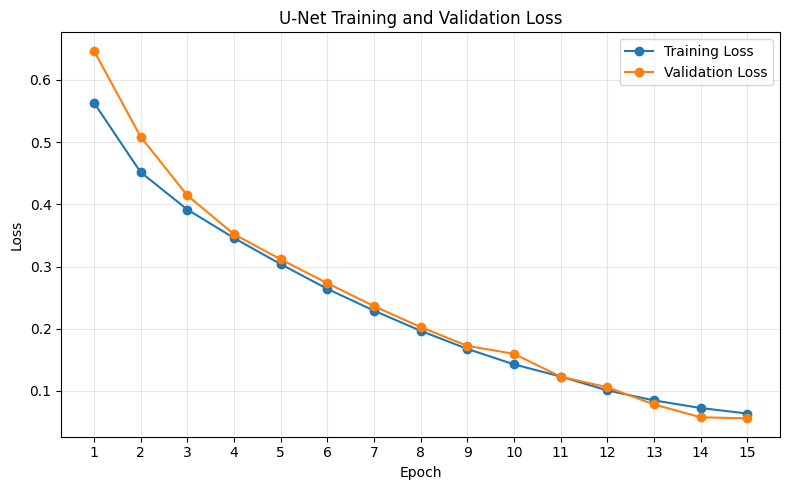

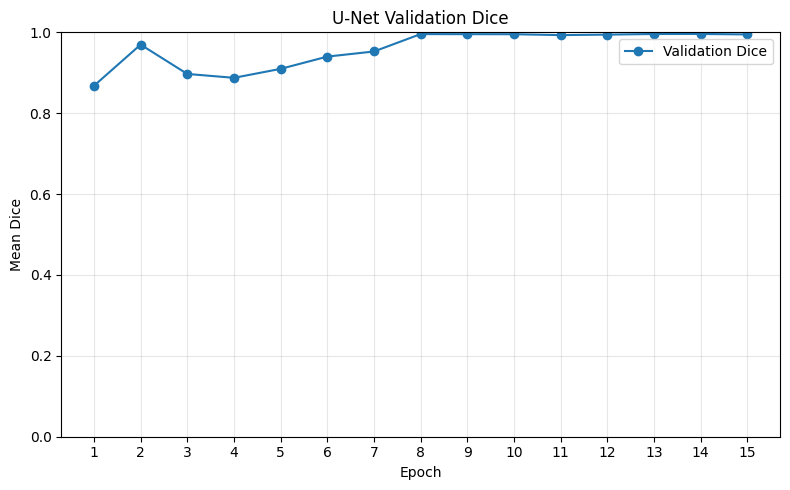

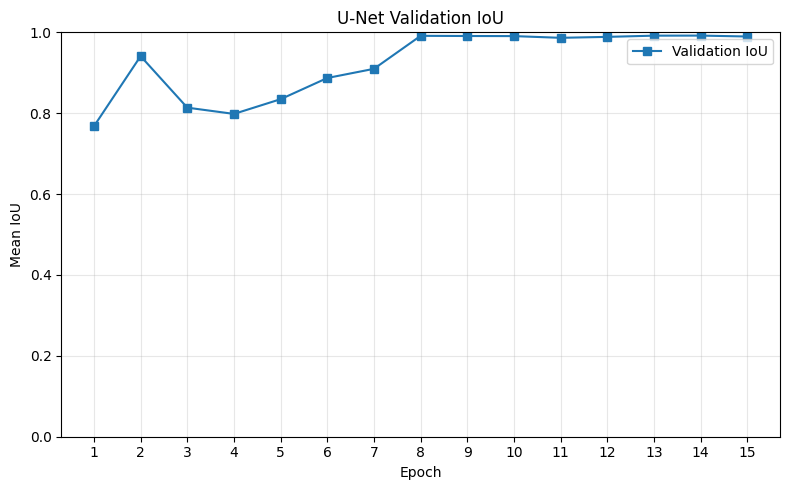

In [14]:
epochs = range(
    1,
    NUM_EPOCHS + 1
)


# ============================================================
# Loss curve
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "U-Net Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(
    list(epochs)
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(
    FIGURE_DIR,
    "unet_loss_curves.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Dice curve
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["val_dice"],
    marker="o",
    label="Validation Dice"
)

plt.title(
    "U-Net Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Dice")

plt.xticks(
    list(epochs)
)

plt.ylim(
    0,
    1
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

dice_curve_path = os.path.join(
    FIGURE_DIR,
    "unet_validation_dice.png"
)

plt.savefig(
    dice_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# IoU curve
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["val_iou"],
    marker="s",
    label="Validation IoU"
)

plt.title(
    "U-Net Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Mean IoU")

plt.xticks(
    list(epochs)
)

plt.ylim(
    0,
    1
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

iou_curve_path = os.path.join(
    FIGURE_DIR,
    "unet_validation_iou.png"
)

plt.savefig(
    iou_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Validation Predictions

To inspect qualitative segmentation performance, three validation images are selected.

Each example shows:

1. Original input image
2. Ground-truth segmentation mask
3. U-Net predicted mask

The qualitative examples are important because a single mean Dice/IoU value does not reveal where the model succeeds or fails. In particular, visual inspection can reveal missed objects, merged objects, false-positive regions and boundary errors.

In [16]:
def get_prediction(
    model,
    image_tensor,
    device,
    threshold=0.5
):
    """
    Generate a binary segmentation prediction
    from a single image tensor.
    """

    model.eval()

    with torch.no_grad():

        image_batch = (
            image_tensor
            .unsqueeze(0)
            .to(device)
        )

        logits = model(
            image_batch
        )

        probabilities = torch.sigmoid(
            logits
        )

        prediction = (
            probabilities >= threshold
        ).float()

    return prediction.squeeze().cpu().numpy()


def tensor_to_display_image(
    image_tensor
):
    """
    Convert CHW tensor in [0,1] to HWC
    NumPy array for matplotlib.
    """

    return (
        image_tensor
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

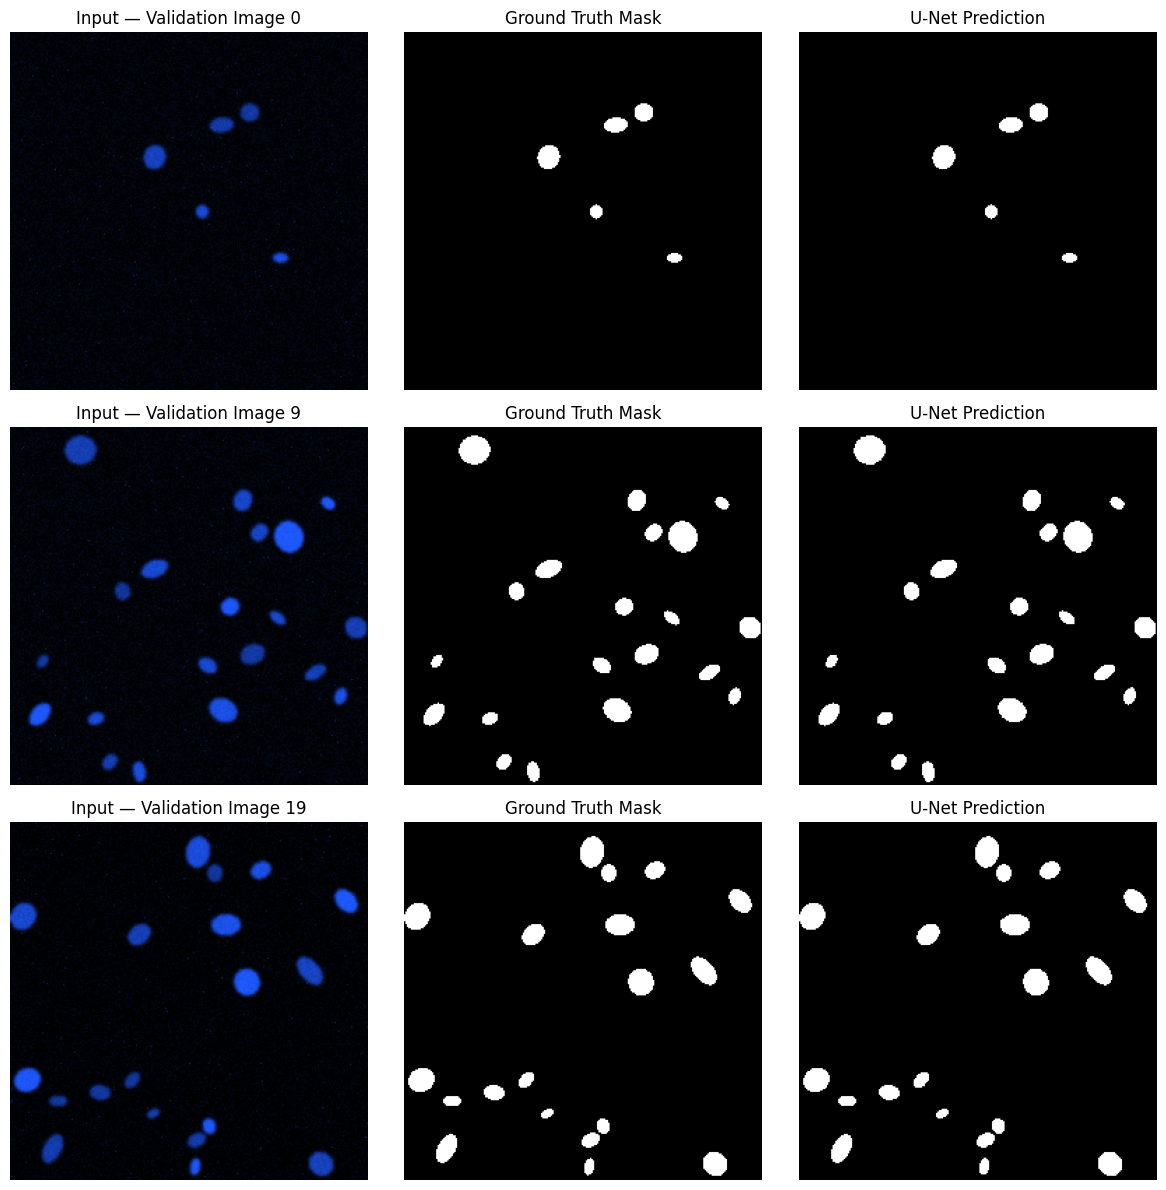

In [17]:
# ============================================================
# Select three validation examples
# ============================================================

num_examples = min(
    3,
    len(val_dataset)
)

example_indices = np.linspace(
    0,
    len(val_dataset) - 1,
    num_examples,
    dtype=int
)


# ============================================================
# Plot predictions
# ============================================================

fig, axes = plt.subplots(
    num_examples,
    3,
    figsize=(12, 4 * num_examples)
)

if num_examples == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )


for row, idx in enumerate(
    example_indices
):

    image_tensor, mask_tensor = (
        val_dataset[idx]
    )

    prediction = get_prediction(
        best_model,
        image_tensor,
        device
    )

    image_display = (
        tensor_to_display_image(
            image_tensor
        )
    )

    mask_display = (
        mask_tensor
        .squeeze()
        .numpy()
    )

    axes[row, 0].imshow(
        image_display
    )

    axes[row, 0].set_title(
        f"Input — Validation Image {idx}"
    )

    axes[row, 0].axis("off")


    axes[row, 1].imshow(
        mask_display,
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Ground Truth Mask"
    )

    axes[row, 1].axis("off")


    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 2].set_title(
        "U-Net Prediction"
    )

    axes[row, 2].axis("off")


plt.tight_layout()

prediction_figure_path = os.path.join(
    FIGURE_DIR,
    "unet_validation_predictions.png"
)

plt.savefig(
    prediction_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Per-Image Validation Error Analysis

Mean Dice and IoU summarise the overall validation performance, but they can hide difficult individual images.

To identify where the model makes mistakes, Dice and IoU are calculated separately for every validation image. The lowest-scoring examples are then visualised.

This analysis helps determine whether errors are associated with particular image characteristics, such as low object density, small nuclei, touching objects, irregular boundaries, or objects close to the image edge.

In [21]:
# ============================================================
# Per-image Dice and IoU analysis
# ============================================================

def per_image_metrics(
    model,
    dataset,
    device,
    threshold=0.5,
    smooth=1e-6
):
    """
    Calculate Dice and IoU separately for every
    validation image.
    """

    model.eval()

    results = []

    with torch.no_grad():

        for idx in range(len(dataset)):

            image, mask = dataset[idx]

            image_batch = (
                image
                .unsqueeze(0)
                .to(device)
            )

            mask_batch = (
                mask
                .unsqueeze(0)
                .to(device)
            )

            logits = model(
                image_batch
            )

            probabilities = torch.sigmoid(
                logits
            )

            prediction = (
                probabilities >= threshold
            ).float()

            pred = prediction.flatten()
            target = mask_batch.flatten()

            intersection = (
                pred * target
            ).sum()

            dice = (
                2 * intersection + smooth
            ) / (
                pred.sum()
                + target.sum()
                + smooth
            )

            union = (
                pred.sum()
                + target.sum()
                - intersection
            )

            iou = (
                intersection + smooth
            ) / (
                union + smooth
            )

            results.append({
                "image_index": idx,
                "dice": dice.item(),
                "iou": iou.item()
            })

    return results


per_image_results = per_image_metrics(
    best_model,
    val_dataset,
    device
)


# Sort by Dice
worst_images = sorted(
    per_image_results,
    key=lambda x: x["dice"]
)

print("Lowest-performing validation images")
print("=" * 60)

for result in worst_images[:5]:

    print(
        f"Image {result['image_index']:>3} | "
        f"Dice: {result['dice']:.4f} | "
        f"IoU: {result['iou']:.4f}"
    )

Lowest-performing validation images
Image  12 | Dice: 0.9891 | IoU: 0.9784
Image   1 | Dice: 0.9908 | IoU: 0.9818
Image  18 | Dice: 0.9922 | IoU: 0.9845
Image  15 | Dice: 0.9923 | IoU: 0.9847
Image   6 | Dice: 0.9932 | IoU: 0.9864


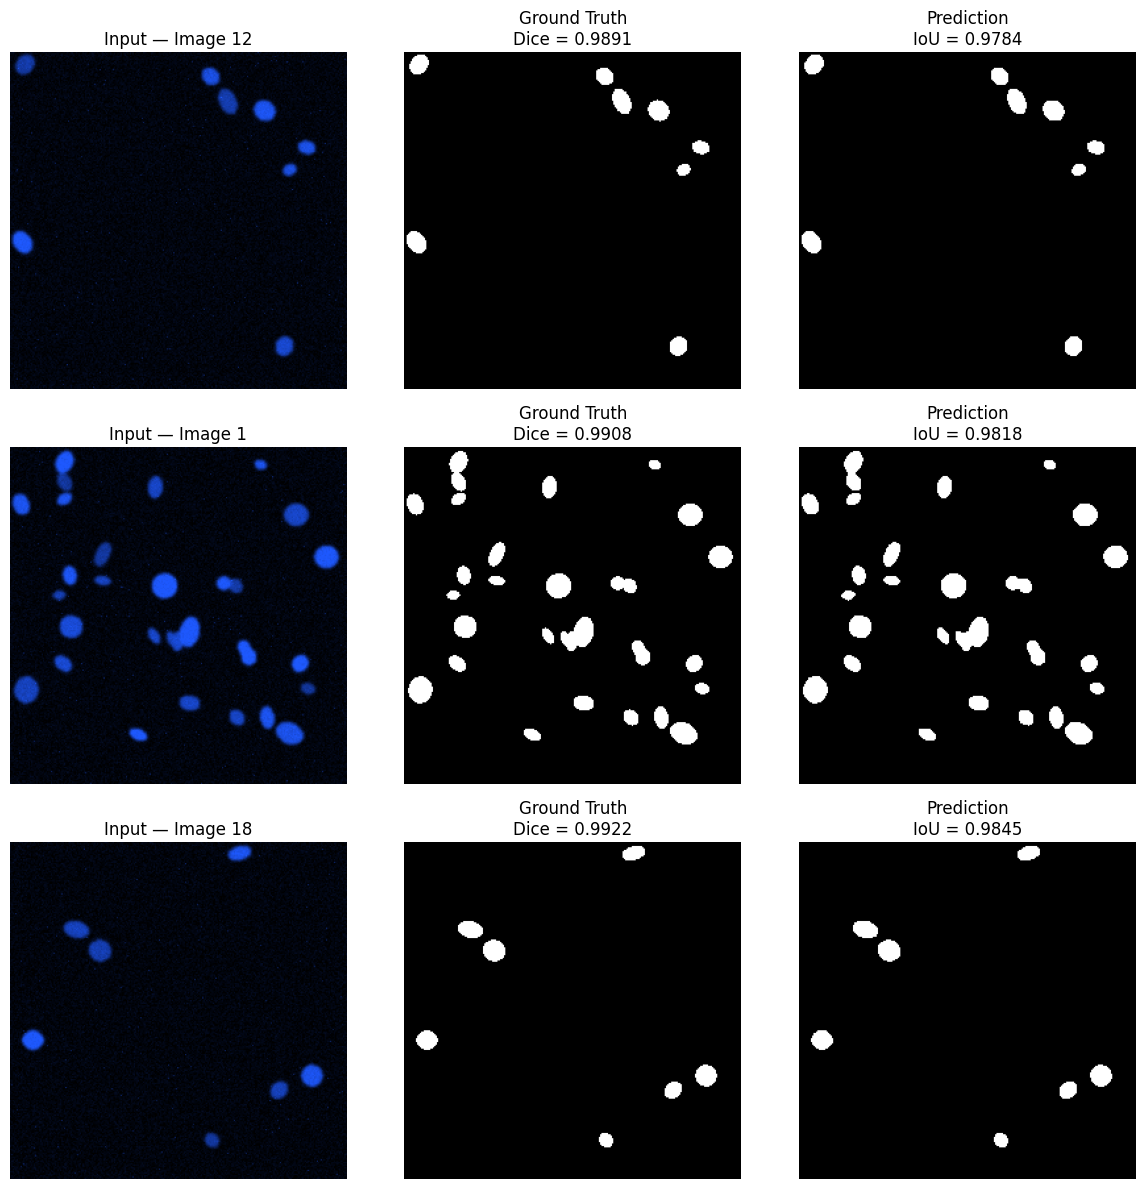

In [22]:
# ============================================================
# Visualise the three lowest-Dice validation images
# ============================================================

worst_three = worst_images[:3]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

for row, result in enumerate(worst_three):

    idx = result["image_index"]

    image_tensor, mask_tensor = (
        val_dataset[idx]
    )

    prediction = get_prediction(
        best_model,
        image_tensor,
        device
    )

    image_display = (
        tensor_to_display_image(
            image_tensor
        )
    )

    mask_display = (
        mask_tensor
        .squeeze()
        .numpy()
    )

    axes[row, 0].imshow(
        image_display
    )

    axes[row, 0].set_title(
        f"Input — Image {idx}"
    )

    axes[row, 0].axis("off")


    axes[row, 1].imshow(
        mask_display,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"Ground Truth\n"
        f"Dice = {result['dice']:.4f}"
    )

    axes[row, 1].axis("off")


    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 2].set_title(
        f"Prediction\n"
        f"IoU = {result['iou']:.4f}"
    )

    axes[row, 2].axis("off")


plt.tight_layout()

worst_cases_path = os.path.join(
    FIGURE_DIR,
    "unet_worst_validation_cases.png"
)

plt.savefig(
    worst_cases_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Final Task 3 Summary

The trained U-Net is evaluated using mean Dice and IoU on the held-out validation set.

Dice measures the overlap between the predicted and ground-truth foreground regions, while IoU measures the intersection relative to the union of the two regions.

The numerical metrics should be interpreted together with the prediction panels and training curves. A high mean score does not guarantee equally good segmentation on every image, particularly when object size, density or contrast varies across the dataset.

The best model checkpoint is retained for use by the later post-processing and hybrid pipeline notebooks.

In [18]:
print("=" * 70)
print("TASK 3 — U-NET SUMMARY")
print("=" * 70)

print(
    f"Training epochs       : {NUM_EPOCHS}"
)

print(
    f"Training samples      : {len(train_dataset)}"
)

print(
    f"Validation samples    : {len(val_dataset)}"
)

print(
    f"Loss function         : BCE + Dice"
)

print(
    f"Best validation loss  : {final_val_loss:.4f}"
)

print(
    f"Mean validation Dice  : {final_val_dice:.4f}"
)

print(
    f"Mean validation IoU   : {final_val_iou:.4f}"
)

print(
    f"Best model checkpoint : {CHECKPOINT_PATH}"
)

print("\nFigures saved:")
print(
    " -", loss_curve_path
)
print(
    " -", dice_curve_path
)
print(
    " -", iou_curve_path
)
print(
    " -", prediction_figure_path
)

TASK 3 — U-NET SUMMARY
Training epochs       : 15
Training samples      : 80
Validation samples    : 20
Loss function         : BCE + Dice
Best validation loss  : 0.0559
Mean validation Dice  : 0.9948
Mean validation IoU   : 0.9897
Best model checkpoint : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\models\best_unet_nuclei.pth

Figures saved:
 - C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_loss_curves.png
 - C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_validation_dice.png
 - C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_validation_iou.png
 - C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\figures\unet_validation_predictions.png
